In [2]:
!ls stand

attempt			 games_dict		 meta.json
bin			 games_flog.gz		 order_money_left_caesar
config			 games_flog.gz.PREV	 poor_mans_profiler
daemon.json		 geodata4-tree+ling.bin  push-client
dssm			 geodata6.bin		 secret
dumped_requests.gz	 language		 service_tickets
dumped_requests.gz.PREV  lm			 stand.json
formulas		 log.local.txt		 unified_agent


In [47]:
requests = list()
with open("stand/log.local.txt") as f:
    req = list()
    reqid = None
    for i, line in enumerate(f):
        if line.startswith("seed"):
            if req:
                requests.append((reqid, sorted(req)))
                req = list()
            reqid = "$_" + (line.split()[1] + "_" + line.split()[3])
        else:
            req.append(
                (int(line.split()[0]), float(line.split()[1]))
            )

requests = [r for r in requests if len(r[1]) == 15597]

In [49]:

import numpy as np

In [431]:
games_count = 15597
key_games = np.random.choice(np.arange(games_count), 100, replace=False)
key_reqs = np.random.choice(np.arange(len(requests)), 101, replace=False)
key_games, key_reqs

(array([14558,  7013, 12731,  4615,  3230, 11485,  1663,   137, 14684,
          466,  6723,  6249, 11122,  1147,  4921,  6874,  1480,  6021,
         9639, 14167, 11230,  9044, 12990,  5464,   660,  1465, 10470,
         3505,  7343,  9563,  1709, 11686,  8104,  7188, 10418, 15284,
        14190, 12013, 10920,  5715, 13501,   990,  3549,  6141,  3214,
         9354, 11234,  9812,  4590,  4093, 13712,  7338, 10760,  6032,
         5166,  6642,  7400, 14518,  5262, 13224,  1463,   328,  7506,
        10660, 12769,  5499, 13038, 11063, 11551,  9261,  1851,  4015,
        12111,  6636,  4017,  6553,  5330,  2351,  8946, 10388,  1571,
         3668, 14838,   349, 12309, 14404,  4647,  4291, 15435,  9971,
        14571, 11018, 11091, 13942, 10060,  9767,  6502,  9565,  2939,
         7559]),
 array([422, 668,   8,   7, 763, 877, 952, 798,  74, 412, 262, 462,  28,
        272, 555, 605, 766,  47,  49, 268, 781, 249, 375, 773, 407,  52,
         19, 177,  16, 374,  27, 239,  18, 413, 594, 547

In [432]:
len(requests)

977

In [433]:
requests[0][1]

[(96240, -0.06395813823),
 (96243, 0.3556832671),
 (96245, 0.01147340238),
 (96247, 0.2106917799),
 (96248, 0.3033665419),
 (96249, 0.2424320132),
 (96250, 0.2946935892),
 (96252, 0.1217022166),
 (96253, 0.0481553711),
 (96254, -0.07273987681),
 (96255, -0.1148615777),
 (96256, 0.07665453851),
 (96258, 0.01710299402),
 (96261, -0.08164996654),
 (96262, -0.05543139204),
 (96263, 0.1507502645),
 (96264, 0.08011642843),
 (96265, 0.1418123543),
 (96266, 0.1985082179),
 (96269, 0.1920046061),
 (96275, 0.04444029555),
 (96276, 0.1310847104),
 (96278, -0.1028323397),
 (96279, 0.06770322472),
 (96282, -0.07516989112),
 (96283, 0.3768547475),
 (96285, 0.3601410985),
 (96287, 0.181518048),
 (96289, 0.1076573133),
 (96290, -0.1609062999),
 (96291, 0.7252597809),
 (96292, 0.0008069761097),
 (96293, 0.1713558435),
 (96294, 0.2931161225),
 (96296, 0.2920092642),
 (96298, -0.02442803606),
 (96299, 0.2482111156),
 (96300, 0.7015113235),
 (96302, -0.2105030119),
 (96303, -0.1553291678),
 (96306, 0.8526

In [434]:
embed_users = np.array([
    np.array([r_i[1][i][1] for i in key_games])
    for r_i in requests
])
embed_users_mean = embed_users.mean(axis = 0)
# embed_users = embed_users - embed_users_mean
embed_users.shape

(977, 100)

In [435]:
embed_games = np.array([
    np.array([requests[r_i][1][g_i][1] for r_i in key_reqs])
    for g_i in range(games_count)
])
embed_games_mean = embed_games.mean(axis = 0)
# embed_games = embed_games - embed_games_mean
embed_games.shape

(15597, 101)

In [436]:
games_top = embed_games.mean(axis = 1)

In [437]:
games2users = np.array([
    embed_games[g_i]
    for g_i in key_games
])
games2users.shape

(100, 101)

In [554]:
core_users_scores = np.array([
    np.array([g_i[1] for g_i in requests[r_i][1]])
    for r_i in key_reqs
])
core_users_scores.shape

(101, 15597)

In [555]:
embed_users.shape

(977, 100)

In [556]:
core_users_embs = embed_users[key_reqs]
core_users_embs.shape

(101, 100)

In [558]:
ge_users = (embed_users.T / embed_users.mean(axis=1)).T @ games2users
# ge_users = embed_users @ games2users
ge_users.shape

(977, 101)

In [591]:
import tensorflow as tf
initializer = tf.keras.initializers.GlorotUniform()
values = initializer(shape=games2users.shape)
W = tf.Variable(values / 100., trainable = True) 
W, W.dtype

print("0-loss = ", tf.reduce_mean((core_users_scores - 0) ** 2))
loss = tf.keras.losses.MeanSquaredError()
opt =  tf.keras.optimizers.Adam(learning_rate=0.001)

for i in range(500):
    def loss():
        v = (
            tf.reduce_mean((core_users_scores - core_users_embs @ W @ embed_games.T) ** 2)
            + tf.reduce_mean(W * W) * 5000
        )
        print(v.numpy())
        return v
    
    opt.minimize(loss, [W]).numpy()

0-loss =  tf.Tensor(25.246816802324222, shape=(), dtype=float64)
25.88025
28.624039
24.661917
23.945778
24.786783
23.836145
22.346827
21.86336
22.00352
21.672487
20.846199
20.196045
19.987488
19.828066
19.374746
18.782656
18.392555
18.25083
18.078785
17.695421
17.231804
16.900225
16.717121
16.52683
16.239922
15.929817
15.690995
15.49998
15.275183
15.012021
14.779478
14.606747
14.441626
14.235965
14.014394
13.826868
13.673097
13.514208
13.338076
13.168801
13.01909
12.872642
12.718893
12.571454
12.440422
12.313168
12.177204
12.041462
11.918929
11.804854
11.6881485
11.570927
11.461091
11.356202
11.249743
11.144765
11.047591
10.955091
10.860659
10.766293
10.677747
10.593632
10.509239
10.425608
10.346104
10.26928
10.1924515
10.11725
10.045734
9.97603
9.90631
9.838191
9.772959
9.709163
9.6459675
9.584446
9.524778
9.465969
9.408202
9.352271
9.297632
9.243551
9.1905775
9.139164
9.088705
9.038959
8.99039
8.942913
8.896109
8.850184
8.805407
8.761418
8.7180195
8.675525
8.633968
8.593054
8.552801


In [592]:
tf.reduce_mean(W * W) * 1

<tf.Tensor: shape=(), dtype=float32, numpy=0.00015230356>

In [593]:
from scipy.spatial.distance import cosine

from sklearn.metrics.pairwise import cosine_distances, euclidean_distances

from sklearn.metrics import pairwise 

In [594]:
dir(pairwise)

['DataConversionWarning',
 'KERNEL_PARAMS',
 'PAIRED_DISTANCES',
 'PAIRWISE_BOOLEAN_FUNCTIONS',
 'PAIRWISE_DISTANCE_FUNCTIONS',
 'PAIRWISE_KERNEL_FUNCTIONS',
 'Parallel',
 '_NAN_METRICS',
 '_VALID_METRICS',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_argmin_min_reduce',
 '_check_chunk_size',
 '_chi2_kernel_fast',
 '_deprecate_positional_args',
 '_dist_wrapper',
 '_euclidean_distances_upcast',
 '_get_mask',
 '_num_samples',
 '_pairwise_callable',
 '_parallel_pairwise',
 '_precompute_metric_params',
 '_return_float_dtype',
 '_sparse_manhattan',
 'additive_chi2_kernel',
 'check_array',
 'check_non_negative',
 'check_paired_arrays',
 'check_pairwise_arrays',
 'chi2_kernel',
 'cosine_distances',
 'cosine_similarity',
 'csr_matrix',
 'delayed',
 'distance',
 'distance_metrics',
 'effective_n_jobs',
 'euclidean_distances',
 'gen_batches',
 'gen_even_slices',
 'get_chunk_n_rows',
 'haversine_distances',
 'is_scalar_nan',


(array([1.575291e+06, 5.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 1.000000e+00]),
 array([-3.81614923e-01,  5.75759519e+02,  1.15190065e+03,  1.72804179e+03,
         2.30418292e+03,  2.88032405e+03,  3.45646519e+03,  4.03260632e+03,
         4.60874745e+03,  5.18488859e+03,  5.76102972e+03]),
 <a list of 10 Patch objects>)

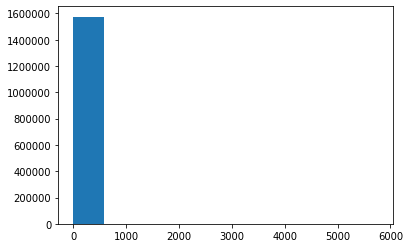

In [605]:
import matplotlib.pyplot as plt
plt.hist(embed_games.flatten())

In [ ]:
1. Расстояние
2. embed_users @ W -> F
3. Как выбирать ключевые элементы = ?
4. Сравниться с продовыми нейронками <--
5. Сравнится с ALS

Эксперименты в духе коллег: RPG?
    - см 4 + считаем #вычислений катбуста + приближение топа катбуста
    - полносвязная нейронка
    - АБ
    
    


99. Профит в проде

In [597]:
rank_e = np.argsort(euclidean_distances(ge_users, embed_games), axis=1)
rank_d = np.argsort(-ge_users @ embed_games.T, axis=1)
rank_c = np.argsort(cosine_distances(ge_users, embed_games), axis=1)
rank_w = np.argsort(-embed_users @ W @ embed_games.T, axis=1)

topsize = 100
games_top_ids = [requests[0][1][g_i][0] for g_i in np.argsort(-games_top)[:topsize]]

for rank, v in ((rank_e, "e"), (rank_d, "d"), (rank_c, "c"), (rank_w, "w")):

    rec_res  = list()
    rand_res = list()
    top_res = list()
    for req_id in range(len(requests)):
        if req_id not in key_reqs:
            rec = [requests[req_id][1][rank[req_id][i]][0] for i in range(topsize)]
            real = [x[1] for x in sorted([(-r[1], r[0]) for r in requests[req_id][1]])[:topsize]]
            random = np.random.choice([r_i[0] for r_i in requests[0][1]], topsize, replace=False)
            top = games_top_ids
            
            ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

            rec_res.append(ev(rec, real) / float(topsize))
            rand_res.append(ev(random, real) / float(topsize))
            top_res.append(ev(top, real) / float(topsize))

    print(v, "->", np.mean(rec_res), np.mean(rand_res), np.mean(top_res))

e -> 0.5015182648401827 0.00654109589041096 0.46767123287671236
d -> 0.49687214611872144 0.006232876712328768 0.46767123287671236
c -> 0.19534246575342465 0.0064383561643835616 0.46767123287671236
w -> 0.5583219178082192 0.00636986301369863 0.46767123287671236


In [598]:
rank_e = np.argsort(euclidean_distances(ge_users, embed_games), axis=1)
rank_d = np.argsort(-ge_users @ embed_games.T, axis=1)
rank_c = np.argsort(cosine_distances(ge_users, embed_games), axis=1)
rank_w = np.argsort(-embed_users @ W @ embed_games.T, axis=1)

topsize = 50
games_top_ids = [requests[0][1][g_i][0] for g_i in np.argsort(-games_top)[:topsize]]

for rank, v in ((rank_e, "e"), (rank_d, "d"), (rank_c, "c"), (rank_w, "w")):

    rec_res  = list()
    rand_res = list()
    top_res = list()
    for req_id in range(len(requests)):
        if req_id not in key_reqs:
            rec = [requests[req_id][1][rank[req_id][i]][0] for i in range(topsize)]
            real = [x[1] for x in sorted([(-r[1], r[0]) for r in requests[req_id][1]])[:topsize]]
            random = np.random.choice([r_i[0] for r_i in requests[0][1]], topsize, replace=False)
            top = games_top_ids
            
            ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

            rec_res.append(ev(rec, real) / float(topsize))
            rand_res.append(ev(random, real) / float(topsize))
            top_res.append(ev(top, real) / float(topsize))

    print(v, "->", np.mean(rec_res), np.mean(rand_res), np.mean(top_res))

e -> 0.39970319634703194 0.0034474885844748854 0.3476027397260274
d -> 0.3849771689497717 0.003356164383561644 0.3476027397260274
c -> 0.13173515981735162 0.003470319634703196 0.3476027397260274
w -> 0.4580365296803653 0.003082191780821918 0.3476027397260274


In [599]:
import tensorflow as tf
initializer = tf.keras.initializers.GlorotUniform()
values = initializer(shape=games2users.shape)
W = tf.Variable(values / 100., trainable = True) 
W, W.dtype

print("0-loss = ", tf.reduce_mean((core_users_scores - 0) ** 2))
loss = tf.keras.losses.MeanSquaredError()
opt =  tf.keras.optimizers.Adam(learning_rate=0.001)

for i in range(500):
    def loss():
        v = (
            tf.reduce_mean((core_users_scores - core_users_embs @ W @ embed_games.T) ** 2)
            + tf.reduce_mean(W * W) * 10000
        )
        print(v.numpy())
        return v
    
    opt.minimize(loss, [W]).numpy()

0-loss =  tf.Tensor(25.246816802324222, shape=(), dtype=float64)
25.211386
27.271753
23.987507
23.48089
23.680815
22.622969
21.503971
21.078836
20.902758
20.383768
19.65528
19.144953
18.905611
18.627813
18.138058
17.60036
17.242193
17.053598
16.828331
16.459654
16.054155
15.754034
15.553177
15.339112
15.062351
14.782913
14.559863
14.365725
14.144747
13.906535
13.7036
13.543606
13.378095
13.178884
12.979956
12.821612
12.689337
12.542324
12.376667
12.223425
12.095562
11.971766
11.837322
11.706361
11.591922
11.482992
11.365809
11.248382
11.144821
11.050027
10.950251
10.846779
10.751256
10.664447
10.5770035
10.487351
10.40214
10.322427
10.242873
10.163023
10.087484
10.016004
9.944244
9.872374
9.804216
9.7395115
9.674905
9.61054
9.548902
9.489644
9.430844
9.373017
9.317381
9.263131
9.209386
9.157039
9.106561
9.05695
9.007898
8.960224
8.913988
8.868449
8.823684
8.780155
8.737561
8.695611
8.654622
8.614656
8.575308
8.5366125
8.49888
8.461959
8.425563
8.389843
8.354935
8.320644
8.286907
8.2538

In [600]:
rank_e = np.argsort(euclidean_distances(ge_users, embed_games), axis=1)
rank_d = np.argsort(-ge_users @ embed_games.T, axis=1)
rank_c = np.argsort(cosine_distances(ge_users, embed_games), axis=1)
rank_w = np.argsort(-embed_users @ W @ embed_games.T, axis=1)

topsize = 50
games_top_ids = [requests[0][1][g_i][0] for g_i in np.argsort(-games_top)[:topsize]]

for rank, v in ((rank_e, "e"), (rank_d, "d"), (rank_c, "c"), (rank_w, "w")):

    rec_res  = list()
    rand_res = list()
    top_res = list()
    for req_id in range(len(requests)):
        if req_id not in key_reqs:
            rec = [requests[req_id][1][rank[req_id][i]][0] for i in range(topsize)]
            real = [x[1] for x in sorted([(-r[1], r[0]) for r in requests[req_id][1]])[:topsize]]
            random = np.random.choice([r_i[0] for r_i in requests[0][1]], topsize, replace=False)
            top = games_top_ids
            
            ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

            rec_res.append(ev(rec, real) / float(topsize))
            rand_res.append(ev(random, real) / float(topsize))
            top_res.append(ev(top, real) / float(topsize))

    print(v, "->", np.mean(rec_res), np.mean(rand_res), np.mean(top_res))

e -> 0.39970319634703194 0.003036529680365297 0.3476027397260274
d -> 0.3849771689497717 0.0026484018264840187 0.3476027397260274
c -> 0.13173515981735162 0.004041095890410959 0.3476027397260274
w -> 0.46878995433789955 0.0031963470319634705 0.3476027397260274


In [601]:
rank_e = np.argsort(euclidean_distances(ge_users, embed_games), axis=1)
rank_d = np.argsort(-ge_users @ embed_games.T, axis=1)
rank_c = np.argsort(cosine_distances(ge_users, embed_games), axis=1)
rank_w = np.argsort(-(embed_users @ W) @ embed_games.T, axis=1)

topsize = 100
games_top_ids = [requests[0][1][g_i][0] for g_i in np.argsort(-games_top)[:topsize]]

for rank, v in ((rank_e, "e"), (rank_d, "d"), (rank_c, "c"), (rank_w, "w")):

    rec_res  = list()
    rand_res = list()
    top_res = list()
    for req_id in range(len(requests)):
        if req_id not in key_reqs:
            rec = [requests[req_id][1][rank[req_id][i]][0] for i in range(topsize)]
            real = [x[1] for x in sorted([(-r[1], r[0]) for r in requests[req_id][1]])[:topsize]]
            random = np.random.choice([r_i[0] for r_i in requests[0][1]], topsize, replace=False)
            top = games_top_ids
            
            ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

            rec_res.append(ev(rec, real) / float(topsize))
            rand_res.append(ev(random, real) / float(topsize))
            top_res.append(ev(top, real) / float(topsize))

    print(v, "->", np.mean(rec_res), np.mean(rand_res), np.mean(top_res))

e -> 0.5015182648401827 0.0065981735159817345 0.46767123287671236
d -> 0.49687214611872144 0.00634703196347032 0.46767123287671236
c -> 0.19534246575342465 0.006210045662100456 0.46767123287671236
w -> 0.5695433789954337 0.0067123287671232885 0.46767123287671236


In [602]:
import tensorflow as tf
initializer = tf.keras.initializers.GlorotUniform()
values = initializer(shape=games2users.shape)
W = tf.Variable(values / 100., trainable = True) 
W, W.dtype

print("0-loss = ", tf.reduce_mean((core_users_scores - 0) ** 2))
loss = tf.keras.losses.MeanSquaredError()
opt =  tf.keras.optimizers.Adam(learning_rate=0.001)

for i in range(500):
    def loss():
        v = (
            tf.reduce_mean((core_users_scores - core_users_embs @ W @ embed_games.T) ** 2)
            + tf.reduce_mean(W * W) * 15000
        )
        print(v.numpy())
        return v
    
    opt.minimize(loss, [W]).numpy()

0-loss =  tf.Tensor(25.246816802324222, shape=(), dtype=float64)
25.816462
27.311192
24.279274
23.622892
23.828875
22.726688
21.480453
21.073217
21.046986
20.576244
19.731203
19.078756
18.850435
18.702099
18.276258
17.67374
17.214064
17.007214
16.853594
16.541233
16.11694
15.772412
15.572518
15.398616
15.135865
14.819701
14.561339
14.387917
14.219799
13.997756
13.758678
13.566521
13.4208
13.267033
13.081117
12.897243
12.747708
12.617914
12.476969
12.325209
12.187395
12.069975
11.953592
11.827763
11.705081
11.597132
11.495957
11.389696
11.2826395
11.184801
11.094059
11.001677
10.907935
10.820129
10.7384615
10.656627
10.573693
10.494644
10.420812
10.348008
10.274634
10.203658
10.13644
10.070772
10.00536
9.941743
9.880692
9.821018
9.762084
9.704708
9.649193
9.594831
9.541496
9.489592
9.438985
9.389317
9.340842
9.293718
9.247504
9.202048
9.157773
9.114692
9.072331
9.030711
8.990172
8.950579
8.911592
8.873376
8.836104
8.799556
8.76358
8.728371
8.693947
8.660116
8.6268635
8.59432
8.562397
8.

In [603]:
rank_e = np.argsort(euclidean_distances(ge_users, embed_games), axis=1)
rank_d = np.argsort(-ge_users @ embed_games.T, axis=1)
rank_c = np.argsort(cosine_distances(ge_users, embed_games), axis=1)
rank_w = np.argsort(-embed_users @ W @ embed_games.T, axis=1)

topsize = 100
games_top_ids = [requests[0][1][g_i][0] for g_i in np.argsort(-games_top)[:topsize]]

for rank, v in ((rank_e, "e"), (rank_d, "d"), (rank_c, "c"), (rank_w, "w")):

    rec_res  = list()
    rand_res = list()
    top_res = list()
    for req_id in range(len(requests)):
        if req_id not in key_reqs:
            rec = [requests[req_id][1][rank[req_id][i]][0] for i in range(topsize)]
            real = [x[1] for x in sorted([(-r[1], r[0]) for r in requests[req_id][1]])[:topsize]]
            random = np.random.choice([r_i[0] for r_i in requests[0][1]], topsize, replace=False)
            top = games_top_ids
            
            ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

            rec_res.append(ev(rec, real) / float(topsize))
            rand_res.append(ev(random, real) / float(topsize))
            top_res.append(ev(top, real) / float(topsize))

    print(v, "->", np.mean(rec_res), np.mean(rand_res), np.mean(top_res))

e -> 0.5015182648401827 0.006141552511415524 0.46767123287671236
d -> 0.49687214611872144 0.007146118721461187 0.46767123287671236
c -> 0.19534246575342465 0.006415525114155252 0.46767123287671236
w -> 0.5740525114155252 0.006164383561643835 0.46767123287671236


In [606]:
import tensorflow as tf
initializer = tf.keras.initializers.GlorotUniform()
values = initializer(shape=games2users.shape)
W = tf.Variable(values / 100., trainable = True) 
W, W.dtype

print("0-loss = ", tf.reduce_mean((core_users_scores - 0) ** 2))
loss = tf.keras.losses.MeanSquaredError()
opt =  tf.keras.optimizers.Adam(learning_rate=0.001)

for i in range(500):
    def loss():
        v = (
            tf.reduce_mean((core_users_scores - core_users_embs @ W @ embed_games.T) ** 2)
            + tf.reduce_mean(W * W) * 20000
        )
        print(v.numpy())
        return v
    
    opt.minimize(loss, [W]).numpy()

0-loss =  tf.Tensor(25.246816802324222, shape=(), dtype=float64)
26.422459
28.197329
25.221926
24.018677
24.491787
23.901882
22.659292
22.023773
22.030987
21.784807
21.034544
20.283726
19.962175
19.88794
19.619099
19.075665
18.552872
18.279366
18.134724
17.866215
17.44464
17.062471
16.850163
16.711086
16.478823
16.147476
15.852319
15.667517
15.516025
15.30006
15.0406
14.828211
14.682628
14.5328245
14.332257
14.122829
13.960547
13.831496
13.683692
13.510945
13.353626
13.228215
13.10505
12.962081
12.818453
12.697578
12.589202
12.471386
12.347311
12.234828
12.134283
12.0313835
11.923984
11.8232975
11.732234
11.641815
11.548499
11.458711
11.375509
11.294123
11.212061
11.132777
11.057893
10.984519
10.911332
10.840387
10.772488
10.706078
10.640656
10.577195
10.515663
10.455272
10.396155
10.338769
10.282797
10.227935
10.174421
10.122247
10.071063
10.020961
9.9721775
9.924467
9.877609
9.831811
9.787096
9.743202
9.700134
9.658108
9.616983
9.576545
9.536914
9.498182
9.460171
9.422821
9.386262
9.

In [607]:
rank_e = np.argsort(euclidean_distances(ge_users, embed_games), axis=1)
rank_d = np.argsort(-ge_users @ embed_games.T, axis=1)
rank_c = np.argsort(cosine_distances(ge_users, embed_games), axis=1)
rank_w = np.argsort(-embed_users @ W @ embed_games.T, axis=1)

topsize = 100
games_top_ids = [requests[0][1][g_i][0] for g_i in np.argsort(-games_top)[:topsize]]

for rank, v in ((rank_e, "e"), (rank_d, "d"), (rank_c, "c"), (rank_w, "w")):

    rec_res  = list()
    rand_res = list()
    top_res = list()
    for req_id in range(len(requests)):
        if req_id not in key_reqs:
            rec = [requests[req_id][1][rank[req_id][i]][0] for i in range(topsize)]
            real = [x[1] for x in sorted([(-r[1], r[0]) for r in requests[req_id][1]])[:topsize]]
            random = np.random.choice([r_i[0] for r_i in requests[0][1]], topsize, replace=False)
            top = games_top_ids
            
            ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

            rec_res.append(ev(rec, real) / float(topsize))
            rand_res.append(ev(random, real) / float(topsize))
            top_res.append(ev(top, real) / float(topsize))

    print(v, "->", np.mean(rec_res), np.mean(rand_res), np.mean(top_res))

e -> 0.5015182648401827 0.006164383561643836 0.46767123287671236
d -> 0.49687214611872144 0.006073059360730594 0.46767123287671236
c -> 0.19534246575342465 0.006769406392694063 0.46767123287671236
w -> 0.5759931506849314 0.00660958904109589 0.46767123287671236


In [608]:
import tensorflow as tf
initializer = tf.keras.initializers.GlorotUniform()
values = initializer(shape=games2users.shape)
W = tf.Variable(values / 100., trainable = True) 
W, W.dtype

print("0-loss = ", tf.reduce_mean((core_users_scores - 0) ** 2))
loss = tf.keras.losses.MeanSquaredError()
opt =  tf.keras.optimizers.Adam(learning_rate=0.001)

for i in range(1000):
    def loss():
        v = (
            tf.reduce_mean((core_users_scores - core_users_embs @ W @ embed_games.T) ** 2)
            + tf.reduce_mean(W * W) * 20000
        )
        print(v.numpy())
        return v
    
    opt.minimize(loss, [W]).numpy()

0-loss =  tf.Tensor(25.246816802324222, shape=(), dtype=float64)
25.752264
28.16531
24.501078
24.013487
24.491163
23.396357
22.233036
21.951038
21.864399
21.25031
20.441607
20.02317
19.924488
19.648338
19.064337
18.49881
18.219315
18.097559
17.846622
17.433144
17.055319
16.824482
16.639835
16.379372
16.075819
15.830103
15.644814
15.4376955
15.185071
14.953433
14.784421
14.630636
14.436802
14.223695
14.044759
13.901068
13.750694
13.581136
13.420501
13.282609
13.147466
13.002296
12.863024
12.742047
12.625534
12.499077
12.372062
12.259096
12.15556
12.048734
11.939809
11.838187
11.743655
11.649108
11.554379
11.464612
11.379467
11.294706
11.210812
11.131205
11.055032
10.9791355
10.904233
10.832883
10.764216
10.696032
10.629046
10.564751
10.502225
10.440434
10.38038
10.322524
10.265577
10.209297
10.154917
10.102319
10.050308
9.999118
9.949641
9.901393
9.8537035
9.80711
9.761872
9.717396
9.67363
9.631039
9.5893955
9.548333
9.5081625
9.469021
9.430525
9.392659
9.355686
9.31944
9.283786
9.24887

6.5156355
6.5155697
6.515508
6.5154448
6.515379
6.515316
6.5152545
6.5151906
6.515131
6.5150704
6.515008
6.514949
6.5148897
6.5148277
6.5147686
6.514709
6.5146503
6.514595
6.514539
6.514482
6.514423
6.514365
6.514311
6.514257
6.514201
6.514144
6.5140915
6.514038
6.5139847
6.5139318
6.513879
6.5138264
6.513774
6.5137224
6.513668
6.5136204
6.513569
6.513517
6.5134673
6.51342
6.5133705
6.5133214
6.513273
6.513224
6.513177
6.5131288
6.513084
6.5130377
6.51299
6.512944
6.512897
6.5128503
6.5128074
6.5127606
6.512718
6.5126753
6.512632
6.5125875
6.5125437
6.512501
6.512459
6.5124154
6.512373
6.512331
6.51229
6.5122495
6.512208
6.5121684
6.512129
6.5120897
6.512048
6.51201
6.5119724
6.5119314
6.5118923
6.5118556
6.5118184
6.5117784
6.5117435
6.5117064
6.51167
6.511634
6.5115957
6.5115604
6.5115256
6.5114865
6.511452
6.5114183
6.5113845
6.511348
6.5113144
6.5112815
6.511247
6.5112114
6.51118
6.5111485
6.511116
6.5110817
6.5110474
6.511016
6.5109844
6.510953
6.510924
6.510892
6.51086
6.51083
6.

In [609]:
rank_e = np.argsort(euclidean_distances(ge_users, embed_games), axis=1)
rank_d = np.argsort(-ge_users @ embed_games.T, axis=1)
rank_c = np.argsort(cosine_distances(ge_users, embed_games), axis=1)
rank_w = np.argsort(-embed_users @ W @ embed_games.T, axis=1)

topsize = 100
games_top_ids = [requests[0][1][g_i][0] for g_i in np.argsort(-games_top)[:topsize]]

for rank, v in ((rank_e, "e"), (rank_d, "d"), (rank_c, "c"), (rank_w, "w")):

    rec_res  = list()
    rand_res = list()
    top_res = list()
    for req_id in range(len(requests)):
        if req_id not in key_reqs:
            rec = [requests[req_id][1][rank[req_id][i]][0] for i in range(topsize)]
            real = [x[1] for x in sorted([(-r[1], r[0]) for r in requests[req_id][1]])[:topsize]]
            random = np.random.choice([r_i[0] for r_i in requests[0][1]], topsize, replace=False)
            top = games_top_ids
            
            ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

            rec_res.append(ev(rec, real) / float(topsize))
            rand_res.append(ev(random, real) / float(topsize))
            top_res.append(ev(top, real) / float(topsize))

    print(v, "->", np.mean(rec_res), np.mean(rand_res), np.mean(top_res))

e -> 0.5015182648401827 0.006255707762557078 0.46767123287671236
d -> 0.49687214611872144 0.00632420091324201 0.46767123287671236
c -> 0.19534246575342465 0.006198630136986301 0.46767123287671236
w -> 0.5761986301369864 0.006449771689497717 0.46767123287671236


In [610]:
import tensorflow as tf
initializer = tf.keras.initializers.GlorotUniform()
values = initializer(shape=games2users.shape)
W = tf.Variable(values / 100., trainable = True) 
W, W.dtype

print("0-loss = ", tf.reduce_mean((core_users_scores - 0) ** 2))
loss = tf.keras.losses.MeanSquaredError()
opt =  tf.keras.optimizers.Adam(learning_rate=0.001)

for i in range(5000):
    def loss():
        v = (
            tf.reduce_mean((core_users_scores - core_users_embs @ W @ embed_games.T) ** 2)
            + tf.reduce_mean(W * W) * 20000
        )
        print(v.numpy())
        return v
    
    opt.minimize(loss, [W]).numpy()

0-loss =  tf.Tensor(25.246816802324222, shape=(), dtype=float64)
26.356148
27.705112
24.977888
23.742723
24.002878
23.486565
22.50448
22.007528
21.850069
21.408648
20.686283
20.126455
19.89282
19.697788
19.303274
18.811152
18.446661
18.224878
17.968885
17.602228
17.23343
16.973404
16.782759
16.554024
16.271229
16.00619
15.794055
15.58956
15.356239
15.125068
14.937067
14.775583
14.596237
14.396715
14.211426
14.052375
13.896477
13.731021
13.572068
13.430891
13.294467
13.151186
13.010401
12.881962
12.758244
12.631057
12.5077505
12.395884
12.28794
12.175522
12.064483
11.962717
11.865801
11.76719
11.670592
11.580862
11.493868
11.405344
11.3192835
11.239204
11.161197
11.082377
11.006182
10.934505
10.863888
10.792894
10.724515
10.659569
10.5955715
10.53218
10.471102
10.411898
10.353227
10.295897
10.240783
10.186838
10.133478
10.081597
10.031252
9.981626
9.93293
9.885712
9.839494
9.793933
9.749477
9.706122
9.663408
9.621532
9.580806
9.540839
9.501434
9.462917
9.425287
9.388243
9.351896
9.31638

6.5163784
6.516306
6.516239
6.5161715
6.5161014
6.5160327
6.5159655
6.5158978
6.515831
6.5157638
6.5157003
6.515634
6.5155697
6.515505
6.51544
6.515376
6.5153117
6.5152497
6.5151873
6.515127
6.5150633
6.5150065
6.514942
6.514884
6.514824
6.514765
6.514707
6.514646
6.5145893
6.514532
6.514474
6.5144205
6.5143633
6.5143056
6.5142484
6.5141954
6.514141
6.514085
6.514031
6.5139785
6.5139265
6.513872
6.513819
6.513768
6.513715
6.5136623
6.513614
6.5135617
6.5135136
6.513464
6.5134144
6.5133643
6.5133157
6.5132675
6.513219
6.5131702
6.5131264
6.5130773
6.513029
6.5129833
6.5129366
6.5128903
6.512847
6.5128
6.5127563
6.5127134
6.5126696
6.5126233
6.512581
6.512537
6.512495
6.512451
6.5124097
6.5123687
6.5123277
6.512284
6.5122447
6.5122023
6.512162
6.512121
6.512083
6.5120425
6.5120044
6.511966
6.511925
6.511888
6.5118475
6.511812
6.511772
6.511737
6.5116987
6.5116625
6.5116277
6.5115895
6.5115523
6.511518
6.5114813
6.511449
6.5114126
6.5113783
6.511342
6.5113106
6.5112753
6.511243
6.5112104


6.5069723
6.5069733
6.5069714
6.5069704
6.506973
6.5069737
6.506972
6.506971
6.506973
6.506973
6.5069723
6.506974
6.506972
6.5069714
6.506974
6.5069723
6.5069714
6.5069733
6.506972
6.506975
6.506975
6.5069714
6.506973
6.506972
6.5069723
6.5069733
6.5069733
6.5069723
6.5069714
6.5069737
6.5069723
6.5069723
6.5069733
6.5069723
6.5069737
6.506972
6.5069714
6.5069714
6.50697
6.506971
6.506972
6.506972
6.506971
6.5069714
6.506971
6.5069723
6.5069714
6.5069704
6.5069714
6.506973
6.5069714
6.506973
6.5069723
6.5069714
6.5069704
6.5069704
6.5069733
6.5069733
6.506972
6.5069714
6.5069704
6.5069704
6.5069737
6.506973
6.5069723
6.5069733
6.506973
6.506972
6.5069714
6.5069723
6.5069733
6.506972
6.5069695
6.5069714
6.5069733
6.506972
6.5069714
6.50697
6.5069695
6.5069704
6.5069695
6.506972
6.506971
6.506969
6.506971
6.5069685
6.5069714
6.506972
6.506971
6.506971
6.5069695
6.5069704
6.50697
6.5069723
6.5069733
6.5069695
6.5069733
6.5069704
6.5069714
6.506972
6.5069723
6.5069757
6.5069714
6.506978
6.

6.50697
6.506971
6.506971
6.506972
6.5069695
6.5069733
6.506969
6.5069695
6.5069714
6.506971
6.506972
6.506973
6.5069733
6.5069776
6.5069838
6.5069942
6.5070076
6.507034
6.5070763
6.5071497
6.5072765
6.5074954
6.5078745
6.5085373
6.5097055
6.5117593
6.515383
6.521762
6.5328484
6.5516768
6.5821466
6.6271787
6.683069
6.730852
6.736656
6.679788
6.5889025
6.527177
6.5308404
6.5756736
6.6050124
6.5860176
6.539668
6.5146694
6.5308037
6.5583005
6.5580997
6.5298996
6.5094423
6.5188017
6.5383887
6.5379906
6.518551
6.5070477
6.515682
6.5273347
6.5240374
6.511718
6.5075574
6.514106
6.519093
6.515435
6.509364
6.508597
6.511841
6.513261
6.5113044
6.509029
6.5086737
6.5095034
6.510008
6.5096908
6.508846
6.508063
6.507964
6.5085545
6.5089436
6.508395
6.5074587
6.5072713
6.507928
6.508366
6.507898
6.5071497
6.5070605
6.5075803
6.507861
6.5075293
6.5070596
6.5070252
6.5073285
6.5074778
6.507303
6.507065
6.5070314
6.5071535
6.5072255
6.507169
6.507077
6.5070357
6.5070534
6.507079
6.5070868
6.5070715
6.5

6.50698
6.506985
6.5069985
6.5070186
6.507057
6.507123
6.5072417
6.5074563
6.507837
6.5085306
6.5097895
6.512084
6.5162745
6.523877
6.537491
6.5611763
6.6000285
6.6568985
6.723355
6.768994
6.752733
6.670693
6.578967
6.539195
6.560321
6.598568
6.605188
6.573865
6.537203
6.5292788
6.5495844
6.5641117
6.5491943
6.5219145
6.516872
6.535498
6.544564
6.527732
6.50965
6.5152073
6.5304575
6.528433
6.5126033
6.5075583
6.5174294
6.5229187
6.5152965
6.5077343
6.5104136
6.515759
6.5143805
6.509591
6.508711
6.5109468
6.5114098
6.5098395
6.5090165
6.5092335
6.5090294
6.508624
6.508869
6.509018
6.50823
6.507504
6.5079536
6.508677
6.508274
6.5072646
6.5071526
6.507903
6.5081534
6.5075064
6.5069814
6.507241
6.507677
6.5075693
6.5071583
6.5070453
6.507249
6.507351
6.507227
6.507101
6.5071073
6.5071397
6.507117
6.5070977
6.507106
6.507091
6.5070376
6.5070157
6.5070577
6.5070896
6.5070467
6.506985
6.5069866
6.507037
6.507051
6.5070105
6.5069733
6.50698
6.50701
6.5070167
6.506993
6.506976
6.506982
6.506990

6.5069704
6.5069704
6.5069714
6.5069714
6.5069695
6.506971
6.506969
6.5069695
6.50697
6.5069704
6.506971
6.5069704
6.50697
6.5069704
6.5069714
6.506971
6.5069714
6.5069704
6.5069714
6.506971
6.5069723
6.5069714
6.506972
6.5069704
6.5069714
6.506972
6.506969
6.5069723
6.5069695
6.5069704
6.5069714
6.5069704
6.5069714
6.506971
6.5069704
6.5069714
6.5069714
6.506969
6.5069723
6.506972
6.506971
6.5069723
6.50697
6.5069704
6.506971
6.5069714
6.506971
6.506972
6.506971
6.5069695
6.506972
6.50697
6.5069704
6.5069714
6.5069714
6.506971
6.506972
6.506971
6.5069704
6.5069714
6.506972
6.5069704
6.5069714
6.506971
6.5069704
6.5069723
6.5069714
6.5069704
6.506971
6.5069714
6.5069704
6.5069704
6.5069704
6.5069704
6.5069704
6.506971
6.5069704
6.506971
6.50697
6.50697
6.506971
6.5069695
6.5069704
6.506971
6.5069704
6.506971
6.5069704
6.5069704
6.5069704
6.5069704
6.5069704
6.506971
6.5069714
6.5069714
6.506971
6.5069704
6.506971
6.5069704
6.5069714
6.5069714
6.5069704
6.5069704
6.5069704
6.5069704
6.5

In [612]:
rank_e = np.argsort(euclidean_distances(ge_users, embed_games), axis=1)
rank_d = np.argsort(-ge_users @ embed_games.T, axis=1)
rank_c = np.argsort(cosine_distances(ge_users, embed_games), axis=1)
rank_w = np.argsort(-embed_users @ W @ embed_games.T, axis=1)

topsize = 100
games_top_ids = [requests[0][1][g_i][0] for g_i in np.argsort(-games_top)[:topsize]]

for rank, v in ((rank_e, "e"), (rank_d, "d"), (rank_c, "c"), (rank_w, "w")):

    rec_res  = list()
    rand_res = list()
    top_res = list()
    for req_id in range(len(requests)):
        if req_id not in key_reqs:
            rec = [requests[req_id][1][rank[req_id][i]][0] for i in range(topsize)]
            real = [x[1] for x in sorted([(-r[1], r[0]) for r in requests[req_id][1]])[:topsize]]
            random = np.random.choice([r_i[0] for r_i in requests[0][1]], topsize, replace=False)
            top = games_top_ids
            
            ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

            rec_res.append(ev(rec, real) / float(topsize))
            rand_res.append(ev(random, real) / float(topsize))
            top_res.append(ev(top, real) / float(topsize))

    print(v, "->", np.mean(rec_res), np.mean(rand_res), np.mean(top_res))

e -> 0.5015182648401827 0.0061757990867579915 0.46767123287671236
d -> 0.49687214611872144 0.006004566210045662 0.46767123287671236
c -> 0.19534246575342465 0.006563926940639269 0.46767123287671236
w -> 0.5762328767123287 0.006381278538812785 0.46767123287671236


In [613]:
import tensorflow as tf
initializer = tf.keras.initializers.GlorotUniform()
values = initializer(shape=games2users.shape)
W = tf.Variable(values / 100., trainable = True) 
W, W.dtype

print("0-loss = ", tf.reduce_mean((core_users_scores - 0) ** 2))
loss = tf.keras.losses.MeanSquaredError()
opt =  tf.keras.optimizers.Adam(learning_rate=0.01)

for i in range(5000):
    def loss():
        v = (
            tf.reduce_mean((core_users_scores - core_users_embs @ W @ embed_games.T) ** 2)
            + tf.reduce_mean(W * W) * 20000
        )
        print(v.numpy())
        return v
    
    opt.minimize(loss, [W]).numpy()

0-loss =  tf.Tensor(25.246816802324222, shape=(), dtype=float64)
25.732538
740.0216
77.57883
223.60202
426.487
279.9788
86.75901
61.709965
162.887
216.30865
157.70436
67.16717
37.11036
77.12249
121.84236
114.37677
64.451065
24.248688
28.259523
60.903465
79.81367
64.43723
32.91655
16.446144
25.723577
43.416855
47.094334
33.934517
19.708155
18.087183
26.183975
30.958788
26.001846
17.700956
15.422825
19.797768
23.273746
20.560825
14.818905
12.605466
15.342963
18.281391
17.243498
13.633903
11.734493
12.912372
14.514991
14.03341
12.239933
11.438404
12.077435
12.55547
11.8687725
10.915616
10.86523
11.406883
11.417991
10.714513
10.182054
10.340834
10.664416
10.515033
10.063045
9.866096
9.98494
10.022936
9.827217
9.652234
9.657772
9.671649
9.542856
9.397124
9.385538
9.422357
9.354443
9.221854
9.164056
9.17945
9.156284
9.0751505
9.01716
9.004445
8.977117
8.918354
8.877921
8.867959
8.841669
8.786287
8.745616
8.735775
8.718599
8.675394
8.636587
8.620148
8.602485
8.568678
8.537727
8.520679
8.50067

6.5091233
6.5090995
6.5090785
6.509057
6.509036
6.5090165
6.5089946
6.508974
6.508955
6.5089345
6.508914
6.508895
6.508876
6.5088553
6.5088353
6.5088167
6.508798
6.5087776
6.5087633
6.5087442
6.508729
6.508707
6.5086884
6.508669
6.5086555
6.5086393
6.508621
6.508603
6.508587
6.5085697
6.5085545
6.5085363
6.508521
6.508505
6.5084906
6.5084734
6.508458
6.5084405
6.5084276
6.508414
6.508399
6.508383
6.508371
6.5083556
6.50834
6.508326
6.508313
6.5083
6.5082846
6.508271
6.50826
6.5082464
6.508231
6.508219
6.5082073
6.508195
6.5081816
6.5081677
6.508156
6.5081434
6.5081325
6.5081186
6.508108
6.5080957
6.508084
6.508071
6.5080633
6.508051
6.5080366
6.508028
6.5080166
6.5080056
6.5079966
6.507984
6.507974
6.507964
6.5079517
6.5079427
6.5079317
6.5079226
6.5079126
6.507901
6.507891
6.507884
6.507873
6.5078626
6.507855
6.507846
6.507838
6.5078278
6.507818
6.5078115
6.507803
6.5077915
6.5077834
6.507776
6.5077667
6.5077577
6.5077515
6.5077415
6.5077333
6.5077243
6.5077186
6.5077105
6.5077
6.5076

6.5069695
6.5069695
6.5069704
6.5069695
6.5069714
6.506972
6.506971
6.5069704
6.5069704
6.50697
6.5069704
6.5069695
6.5069695
6.50697
6.5069704
6.506971
6.5069695
6.5069695
6.50697
6.5069704
6.5069704
6.5069704
6.5069695
6.5069704
6.506971
6.5069704
6.506971
6.5069704
6.506969
6.5069704
6.506969
6.50697
6.5069704
6.5069704
6.5069714
6.50697
6.5069685
6.5069714
6.5069714
6.5069695
6.5069685
6.5069685
6.5069723
6.506971
6.506971
6.50697
6.50697
6.5069733
6.506971
6.5069704
6.5069704
6.5069695
6.5069695
6.5069714
6.5069714
6.5069695
6.50697
6.5069695
6.506971
6.506969
6.5069695
6.5069685
6.50697
6.50697
6.506968
6.5069723
6.5069714
6.506974
6.5069804
6.5069876
6.507006
6.507035
6.50709
6.5071926
6.507383
6.507744
6.5084333
6.5097494
6.5122814
6.517194
6.5267687
6.5455503
6.5825963
6.656043
6.802217
7.0936337
7.67317
8.813056
10.993018
14.908783
21.058916
28.237143
31.574514
25.640602
14.449533
9.770616
14.02654
17.604412
13.697075
8.129091
9.326919
14.046789
13.581469
8.458805
6.6924725
9

15.274807
18.815105
22.025082
23.423454
21.7735
17.19358
11.634071
8.039958
8.131493
10.825219
13.206139
12.904901
10.050886
7.2736654
7.003575
8.87136
10.377964
9.73621
7.7115297
6.52631
7.1565156
8.418583
8.6576605
7.671427
6.6854057
6.6869698
7.3505454
7.6997776
7.352977
6.8080873
6.656929
6.890605
7.081899
6.9911013
6.7790422
6.6922474
6.7449684
6.7822676
6.7300925
6.6651435
6.6660576
6.6974325
6.678381
6.607953
6.5641804
6.592411
6.6440396
6.6422462
6.5798635
6.5236573
6.52896
6.5766034
6.6030865
6.5768337
6.528207
6.507123
6.5265927
6.555685
6.559979
6.537536
6.513891
6.510151
6.5229464
6.533839
6.5313644
6.520343
6.5125403
6.5130763
6.517441
6.5190334
6.5164614
6.513239
6.512426
6.5133443
6.5134115
6.511697
6.509822
6.509665
6.5110683
6.5120873
6.511241
6.5090904
6.507508
6.507717
6.509163
6.510234
6.509882
6.508465
6.507223
6.507042
6.5077586
6.508526
6.5086417
6.5081043
6.507439
6.5071316
6.507262
6.507545
6.5076694
6.5075626
6.507365
6.507246
6.50725
6.5072894
6.50727
6.50718

6.5070896
6.5071306
6.507184
6.507262
6.507372
6.5075235
6.50775
6.50807
6.5085406
6.5092354
6.510265
6.5118117
6.514133
6.51767
6.5230894
6.5314436
6.5444264
6.5647388
6.5967197
6.6473746
6.7280145
6.85687
7.063187
7.393142
7.9176984
8.740213
9.996234
11.825399
14.277612
17.117556
19.591908
20.48146
18.854147
15.142302
11.143981
8.629102
8.181538
9.186304
10.441676
10.941881
10.383283
9.104449
7.8186793
7.2745533
7.694458
8.51442
8.855426
8.292685
7.262869
6.6646414
6.9332743
7.6194115
7.919478
7.5083823
6.8172493
6.5074177
6.76001
7.172806
7.2691503
6.9839582
6.6439414
6.554893
6.703303
6.85461
6.844556
6.7182064
6.61849
6.610183
6.6430583
6.6486006
6.6220837
6.603639
6.610506
6.616077
6.592545
6.55179
6.5318403
6.5501885
6.582556
6.5902896
6.562065
6.5234685
6.5078692
6.523141
6.5479374
6.5562983
6.5421195
6.520477
6.5095034
6.513775
6.5239277
6.5286636
6.5250244
6.5182123
6.514189
6.5140877
6.5149946
6.5143847
6.5126967
6.5119696
6.5129657
6.514224
6.5137653
6.51129
6.5085077
6.507

6.5069714
6.5069695
6.5069714
6.5069695
6.5069704
6.50697
6.5069695
6.5069685
6.5069685
6.5069666
6.50697
6.5069685
6.5069685
6.5069714
6.50697
6.5069704
6.5069695
6.506971
6.50697
6.506972
6.5069695
6.5069714
6.5069723
6.5069757
6.506977
6.50698
6.5069833
6.5069866
6.5069942
6.5070066
6.5070252
6.507052
6.50709
6.5071487
6.5072403
6.507384
6.5076084
6.50796
6.508519
6.5094113
6.510842
6.513165
6.516946
6.52315
6.5334005
6.55043
6.5789
6.6267595
6.707598
6.8446465
7.077444
7.472398
8.13816
9.243347
11.022514
13.726798
17.426939
21.582848
24.605425
24.343483
20.15248
14.372022
10.344897
9.41633
10.588714
11.927943
12.129778
11.212618
9.802476
8.566308
8.18967
8.770536
9.472547
9.277355
8.1124325
7.116706
7.2942333
8.185883
8.47928
7.690246
6.7512293
6.7301126
7.434439
7.7950296
7.321062
6.6454787
6.564695
7.004819
7.269906
7.0232315
6.631605
6.560534
6.7758455
6.9089475
6.7951355
6.6205587
6.5919213
6.671664
6.7000327
6.6389074
6.585863
6.600865
6.629084
6.605214
6.553729
6.542595
6.578

In [614]:
rank_e = np.argsort(euclidean_distances(ge_users, embed_games), axis=1)
rank_d = np.argsort(-ge_users @ embed_games.T, axis=1)
rank_c = np.argsort(cosine_distances(ge_users, embed_games), axis=1)
rank_w = np.argsort(-embed_users @ W @ embed_games.T, axis=1)

topsize = 100
games_top_ids = [requests[0][1][g_i][0] for g_i in np.argsort(-games_top)[:topsize]]

for rank, v in ((rank_e, "e"), (rank_d, "d"), (rank_c, "c"), (rank_w, "w")):

    rec_res  = list()
    rand_res = list()
    top_res = list()
    for req_id in range(len(requests)):
        if req_id not in key_reqs:
            rec = [requests[req_id][1][rank[req_id][i]][0] for i in range(topsize)]
            real = [x[1] for x in sorted([(-r[1], r[0]) for r in requests[req_id][1]])[:topsize]]
            random = np.random.choice([r_i[0] for r_i in requests[0][1]], topsize, replace=False)
            top = games_top_ids
            
            ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

            rec_res.append(ev(rec, real) / float(topsize))
            rand_res.append(ev(random, real) / float(topsize))
            top_res.append(ev(top, real) / float(topsize))

    print(v, "->", np.mean(rec_res), np.mean(rand_res), np.mean(top_res))

e -> 0.5015182648401827 0.006621004566210045 0.46767123287671236
d -> 0.49687214611872144 0.0067808219178082186 0.46767123287671236
c -> 0.19534246575342465 0.006404109589041095 0.46767123287671236
w -> 0.576175799086758 0.006141552511415525 0.46767123287671236


In [ ]:
import tensorflow as tf
initializer = tf.keras.initializers.GlorotUniform()
values = initializer(shape=games2users.shape)
W = tf.Variable(values / 100., trainable = True) 
W, W.dtype

print("0-loss = ", tf.reduce_mean((core_users_scores - 0) ** 2))
loss = tf.keras.losses.MeanSquaredError()
opt =  tf.keras.optimizers.Adam(learning_rate=0.01)

for i in range(5000):
    def loss():
        v = (
            tf.reduce_mean((core_users_scores - core_users_embs @ W @ embed_games.T) ** 2)
            + tf.reduce_mean(W * W) * 20000
        )
        print(v.numpy())
        return v
    
    opt.minimize(loss, [W]).numpy()